In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Improving Employee Retention by Predicting Employee Attrition Using Machine Learning.xlsx - hr_data.csv to Improving Employee Retention by Predicting Employee Attrition Using Machine Learning.xlsx - hr_data.csv


In [ ]:
import pandas as pd

df = pd.read_csv('Improving Employee Retention by Predicting Employee Attrition Using Machine Learning.xlsx - hr_data.csv')
df.sample(5)

,Username,EnterpriseID,StatusPernikahan,JenisKelamin,StatusKepegawaian,Pekerjaan,JenjangKarir,PerformancePegawai,AsalDaerah,HiringPlatform,...,NomorHP,Email,TingkatPendidikan,PernahBekerja,IkutProgramLOP,AlasanResign,TanggalLahir,TanggalHiring,TanggalPenilaianKaryawan,TanggalResign
10,puzzledCake4,105548,Belum_menikah,Pria,FullTime,Software Engineer (Front End),Mid_level,Kurang,Jakarta Timur,CareerBuilder,...,+6281263218xxx,puzzledCake4844@icloud.com,Sarjana,1,1.0,ganti_karir,1975-12-17,2010-7-20,2020-1-14,2019-01-12
34,mereCaribou1,106529,Belum_menikah,Wanita,Outsource,Software Engineer (Back End),Freshgraduate_program,Biasa,Jakarta Utara,LinkedIn,...,+6282206634xxx,mereCaribou1593@gmail.com,Sarjana,1,NaN,masih_bekerja,1988-07-10,2014-9-29,2020-2-18,-
279,peacefulChamois3,106257,Belum_menikah,Wanita,FullTime,Product Design (UI & UX),Freshgraduate_program,Bagus,Jakarta Pusat,LinkedIn,...,+6282208741xxx,peacefulChamois3574@icloud.com,Doktor,1,NaN,NaN,1980-04-18,2013-07-08,2020-1-22,-
235,boredTortoise1,100526,Bercerai,Pria,FullTime,Software Engineer (Back End),Senior_level,Biasa,Jakarta Barat,Indeed,...,+6283858649xxx,boredTortoise1055@hotmail.com,Magister,1,NaN,NaN,1978-11-25,2010-8-30,2012-05-04,-
120,brainyMagpie7,101264,Bercerai,Pria,FullTime,Product Design (UI & UX),Freshgraduate_program,Kurang,Jakarta Barat,Indeed,...,+6285946196xxx,brainyMagpie7608@proton.com,Magister,1,NaN,masih_bekerja,1970-04-25,2017-02-10,2020-2-25,-


In [ ]:
df.isnull().sum()

,0
Username,0
EnterpriseID,0
StatusPernikahan,0
JenisKelamin,0
StatusKepegawaian,0
Pekerjaan,0
JenjangKarir,0
PerformancePegawai,0
AsalDaerah,0
HiringPlatform,0


In [ ]:
#Mengatasi Data Null
num_cols = [
    'SkorKepuasanPegawai',
    'JumlahKeikutsertaanProjek',
    'JumlahKeterlambatanSebulanTerakhir',
    'JumlahKetidakhadiran'
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

In [ ]:
#Kolom Kategori
df['IkutProgramLOP'] = df['IkutProgramLOP'].fillna(df['IkutProgramLOP'].mode()[0])

In [ ]:
df['AlasanResign'] = df['AlasanResign'].fillna('Tidak Resign')

In [ ]:
#Perbaiki Value yang tidak sesuai
df['PernahBekerja'] = df['PernahBekerja'].str.lower()

df['PernahBekerja'] = df['PernahBekerja'].replace({
    'yes': 'Yes',
    'no': 'No'
})

In [ ]:
df['PernahBekerja'].unique()

array(['1', 'Yes'], dtype=object)

In [ ]:
#Hapus Kolom yang tidak perlu
for col in df.columns:
    if df[col].nunique() == 1:
        print(col)

In [ ]:
df.nunique()

,0
Username,285
EnterpriseID,287
StatusPernikahan,5
JenisKelamin,2
StatusKepegawaian,3
Pekerjaan,14
JenjangKarir,3
PerformancePegawai,5
AsalDaerah,5
HiringPlatform,9


In [ ]:
df = df.drop(columns=['Username', 'EnterpriseID', 'Email', 'NomorHP'])

In [ ]:
1. Mengatasi Data Null

Berdasarkan pengecekan missing values, ditemukan beberapa kolom yang memiliki nilai null, seperti SkorKepuasanPegawai, JumlahKeikutsertaanProjek, JumlahKeterlambatanSebulanTerakhir, JumlahKetidakhadiran, IkutProgramLOP, dan AlasanResign.

Penanganan dilakukan dengan:

Mengisi data numerik menggunakan nilai rata-rata (mean)
Mengisi data kategorikal menggunakan modus
Khusus kolom AlasanResign, nilai null diisi dengan "Tidak Resign" karena merepresentasikan pegawai yang masih aktif
2. Mengganti Value Tidak Sesuai

Pada kolom PernahBekerja, ditemukan inkonsistensi penulisan seperti “yes” dan “no”.
Dilakukan standarisasi menjadi:

"Yes"
"No"
3. Membuang Data Tidak Diperlukan

Berdasarkan pengecekan jumlah nilai unik, tidak ditemukan kolom dengan satu nilai unik (konstanta), sehingga tidak ada kolom yang dihapus pada tahap ini.

Sebagai tambahan, kolom seperti Username, EnterpriseID, Email, dan NomorHP dapat dihapus karena hanya bersifat sebagai identifier dan tidak berkontribusi dalam analisis data.

In [ ]:
#Convert Tanggal ke Tahun
df['TanggalHiring'] = pd.to_datetime(df['TanggalHiring'], errors='coerce')
df['TanggalResign'] = pd.to_datetime(df['TanggalResign'], errors='coerce')

df['TahunHiring'] = df['TanggalHiring'].dt.year
df['TahunResign'] = df['TanggalResign'].dt.year

/tmp/ipykernel_17978/1361936347.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['TanggalResign'] = pd.to_datetime(df['TanggalResign'], errors='coerce')


In [ ]:
df[['TanggalResign', 'TahunResign']].head()

,TanggalResign,TahunResign
0,NaT,NaN
1,2018-06-16,2018.0
2,2014-09-24,2014.0
3,NaT,NaN
4,2018-09-06,2018.0


In [ ]:
#Hiring
hiring = df.groupby('TahunHiring').size().reset_index(name='JumlahHiring')

In [ ]:
#Resigm
resign = df.groupby('TahunResign').size().reset_index(name='JumlahResign')

In [ ]:
#Join
df_join = pd.merge(
    hiring,
    resign,
    left_on='TahunHiring',
    right_on='TahunResign',
    how='outer'
)

In [ ]:
#Gabung Tahun jadi 1 kolom
df_join['Tahun'] = df_join['TahunHiring'].fillna(df_join['TahunResign'])
df_join = df_join.sort_values('Tahun')

In [ ]:
#Imputation (Isi Null)
df_join['JumlahHiring'] = df_join['JumlahHiring'].fillna(0)
df_join['JumlahResign'] = df_join['JumlahResign'].fillna(0)

In [ ]:
#Hitung Total & Perubahan
df_join['TotalKaryawan'] = df_join['JumlahHiring'].cumsum()
df_join['Perubahan'] = df_join['JumlahHiring'] - df_join['JumlahResign']

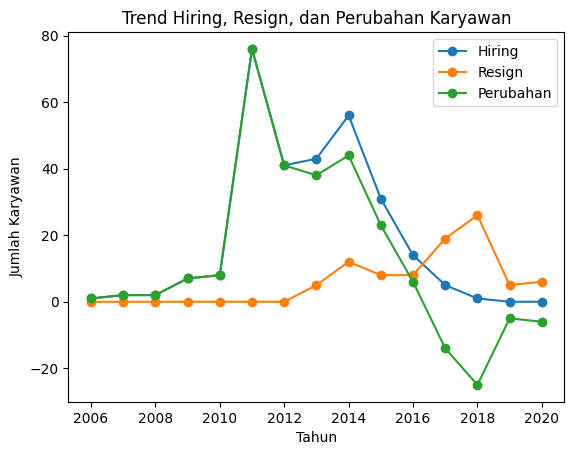

In [ ]:
#Plot (Visualisasi)
import matplotlib.pyplot as plt

plt.figure()

plt.plot(df_join['Tahun'], df_join['JumlahHiring'], marker='o', label='Hiring')
plt.plot(df_join['Tahun'], df_join['JumlahResign'], marker='o', label='Resign')
plt.plot(df_join['Tahun'], df_join['Perubahan'], marker='o', label='Perubahan')

plt.xlabel('Tahun')
plt.ylabel('Jumlah Karyawan')
plt.title('Trend Hiring, Resign, dan Perubahan Karyawan')

plt.legend()
plt.show()

In [ ]:
Grafik tersebut menunjukkan tren jumlah karyawan yang masuk (hiring), keluar (resign), serta perubahan bersih karyawan dari tahun ke tahun.

Pada periode 2011 hingga 2014, perusahaan mengalami pertumbuhan yang signifikan, di mana jumlah karyawan yang direkrut jauh lebih tinggi dibandingkan yang keluar.
Hal ini menyebabkan peningkatan jumlah total karyawan dan menunjukkan fase ekspansi yang kuat.

Namun, mulai tahun 2015, jumlah karyawan yang resign mulai meningkat, sementara jumlah hiring menurun.
Hal ini menyebabkan penurunan pada perubahan bersih karyawan, bahkan menjadi negatif pada beberapa tahun, khususnya sekitar tahun 2017–2018.

Kondisi ini menunjukkan bahwa perusahaan kemungkinan sedang menghadapi tantangan dalam mempertahankan karyawan (employee retention).
Jika tren ini terus berlanjut, hal tersebut dapat menyebabkan penurunan jumlah tenaga kerja dan berpotensi berdampak pada kinerja perusahaan.

In [ ]:
Insight :
Perusahaan mengalami pertumbuhan yang baik pada awal periode, namun setelah tahun 2015 mulai terlihat adanya penurunan kinerja dalam hal retensi karyawan.
 Peningkatan jumlah resign yang tidak diimbangi dengan hiring menunjukkan adanya potensi masalah internal seperti kepuasan kerja, lingkungan kerja, atau kurangnya peluang pengembangan karier.

Oleh karena itu, perusahaan perlu segera melakukan evaluasi dan meningkatkan strategi retensi karyawan, seperti meningkatkan engagement, memberikan kesempatan pengembangan karier, serta menciptakan lingkungan kerja yang lebih kondusif agar dapat menjaga kestabilan jumlah tenaga kerja.

In [ ]:
##Project 3 — Data Analysis & Insight

In [ ]:
print(df.columns)

Index(['StatusPernikahan', 'JenisKelamin', 'StatusKepegawaian', 'Pekerjaan',
       'JenjangKarir', 'PerformancePegawai', 'AsalDaerah', 'HiringPlatform',
       'SkorSurveyEngagement', 'SkorKepuasanPegawai',
       'JumlahKeikutsertaanProjek', 'JumlahKeterlambatanSebulanTerakhir',
       'JumlahKetidakhadiran', 'TingkatPendidikan', 'PernahBekerja',
       'IkutProgramLOP', 'AlasanResign', 'TanggalLahir', 'TanggalHiring',
       'TanggalPenilaianKaryawan', 'TanggalResign', 'TahunHiring',
       'TahunResign'],
      dtype='object')


In [ ]:
# Karyawan resign
df_resign = df[df['TanggalResign'].notna()]

# Karyawan masih aktif
df_active = df[df['TanggalResign'].isna()]

In [ ]:
# Resign
df_resign_agg = df_resign.groupby('Pekerjaan').size().reset_index(name='JumlahResign')

# Aktif
df_active_agg = df_active.groupby('Pekerjaan').size().reset_index(name='JumlahAktif')

In [ ]:
df_join = pd.merge(df_active_agg, df_resign_agg, on='Pekerjaan', how='outer')
df_join = df_join.fillna(0)

In [ ]:
df_join['TotalEmployee'] = df_join['JumlahAktif'] + df_join['JumlahResign']
df_join['PersentaseAktif'] = df_join['JumlahAktif'] / df_join['TotalEmployee'] * 100

In [ ]:
# Ambil hanya yang resign
df_resign = df[df['TanggalResign'].notna()]

# Hitung resign per divisi
df_divisi_resign = df_resign.groupby('Pekerjaan').size().reset_index(name='JumlahResign')

# Ambil yang paling tinggi
divisi_tertinggi = df_divisi_resign.sort_values(by='JumlahResign', ascending=False).iloc[0]['Pekerjaan']

print(divisi_tertinggi)

Software Engineer (Front End)


In [ ]:
df_top_divisi = df_resign[df_resign['Pekerjaan'] == divisi_tertinggi]

In [ ]:
df_agg = df_top_divisi.groupby(['JenjangKarir', 'PerformancePegawai', 'AlasanResign']) \
                     .size().reset_index(name='JumlahResign')

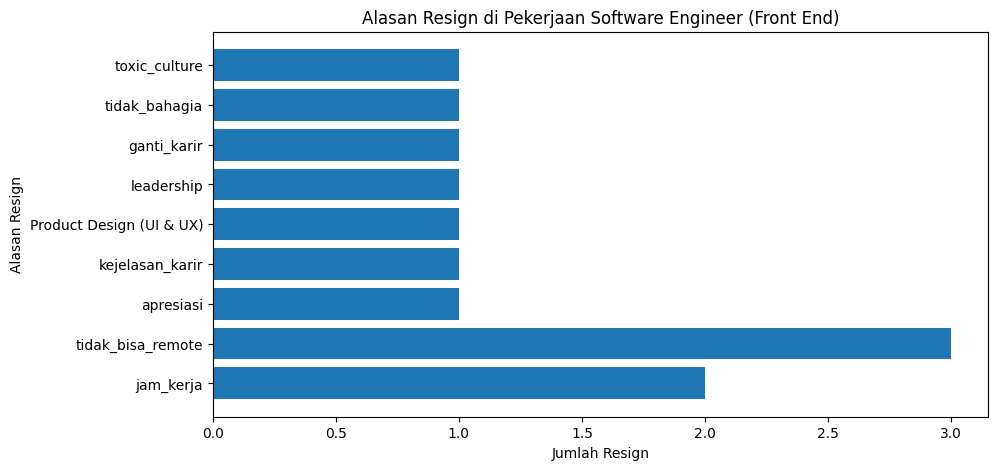

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.barh(df_agg['AlasanResign'], df_agg['JumlahResign'])

plt.xlabel('Jumlah Resign')
plt.ylabel('Alasan Resign')
plt.title(f'Alasan Resign di Pekerjaan {divisi_tertinggi}')

plt.show()

In [ ]:
Berdasarkan grafik, divisi dengan tingkat resign tertinggi adalah Software Engineer (Front End).

Alasan utama karyawan melakukan resign didominasi oleh:

Tidak bisa remote → menjadi alasan paling tinggi
Jam kerja → menunjukkan adanya beban kerja atau work-life balance yang kurang baik
Alasan lain seperti:
toxic culture
tidak bahagia
kurang apresiasi
leadership
kejelasan karir
ganti karir

Namun kontribusinya relatif lebih kecil dibanding dua faktor utama di atas.
Insight :
Faktor fleksibilitas kerja (remote work) adalah penyebab terbesar resign
Diikuti oleh jam kerja, yang mengindikasikan:
kemungkinan overtime tinggi
tekanan kerja besar
Artinya masalah utama bukan di skill atau performa, tapi di sistem kerja & lingkungan kerja

Rekomendasi
Untuk mengurangi tingkat resign, perusahaan sebaiknya:
1. Terapkan kebijakan kerja fleksibel
Work From Home (WFH)
Hybrid working
Remote option
2. Evaluasi jam kerja
Kurangi overtime berlebihan
Terapkan work-life balance
Monitoring workload karyawan
3. Perbaiki budaya kerja
Cegah toxic culture
Tingkatkan komunikasi antara atasan & tim
Program employee engagement
4. Tingkatkan apresiasi & karir
Berikan reward / recognition
Perjelas jenjang karir
Training & development

In [ ]:
## Kesimpulan

Berdasarkan hasil analisis, diketahui bahwa tingkat resign tertinggi terdapat pada divisi Software Engineer (Front End).

Faktor utama yang menyebabkan karyawan melakukan resign adalah tidak adanya fleksibilitas kerja (tidak bisa remote) dan jam kerja yang tinggi.
Kedua faktor ini menunjukkan bahwa work-life balance menjadi permasalahan utama dalam divisi tersebut.

Selain itu, terdapat faktor lain seperti toxic culture, kurangnya apresiasi, serta ketidakjelasan jenjang karir, namun kontribusinya tidak sebesar faktor utama.

Secara keseluruhan, penyebab resign lebih banyak dipengaruhi oleh lingkungan dan sistem kerja dibandingkan faktor individu karyawan.

Untuk mengatasi hal ini, perusahaan disarankan untuk menerapkan kebijakan kerja fleksibel, memperbaiki pengaturan jam kerja, serta meningkatkan budaya kerja dan sistem apresiasi agar dapat meningkatkan retensi karyawan.

In [ ]:
##Project 4 — Machine Learning Modeling

In [ ]:
#cek Missing Value & Duplikat
# Cek missing value
df.isnull().sum()

# Cek data duplikat
df.duplicated().sum()

np.int64(0)

In [ ]:
print(df.columns)

Index(['StatusPernikahan', 'JenisKelamin', 'StatusKepegawaian', 'Pekerjaan',
       'JenjangKarir', 'PerformancePegawai', 'AsalDaerah', 'HiringPlatform',
       'SkorSurveyEngagement', 'SkorKepuasanPegawai',
       'JumlahKeikutsertaanProjek', 'JumlahKeterlambatanSebulanTerakhir',
       'JumlahKetidakhadiran', 'TingkatPendidikan', 'PernahBekerja',
       'IkutProgramLOP', 'AlasanResign', 'TanggalLahir', 'TanggalHiring',
       'TanggalPenilaianKaryawan', 'TanggalResign', 'TahunHiring',
       'TahunResign'],
      dtype='object')


In [ ]:
# Buat target dari TahunResign
df['ResignFlag'] = df['TahunResign'].notna().astype(int)

# Drop kolom yang gak dipakai
df = df.drop(columns=['TahunResign'])

In [ ]:
df = df.drop(columns=[
    'TanggalLahir',
    'TanggalHiring',
    'TanggalPenilaianKaryawan'
], errors='ignore')

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('ResignFlag', axis=1)
y = df['ResignFlag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
X_train = X_train.select_dtypes(exclude=['datetime64[ns]'])
X_test = X_test.select_dtypes(exclude=['datetime64[ns]'])

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cat_cols = X_train.select_dtypes(include='object').columns

ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)

X_train_smote = scaler.fit_transform(X_train_smote)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
lr = LogisticRegression(max_iter=3000)
lr.fit(X_train_smote, y_train_smote)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import classification_report

# Logistic Regression
print("Logistic Regression")
print(classification_report(y_test, lr.predict(X_test)))

# Random Forest
print("Random Forest")
print(classification_report(y_test, rf.predict(X_test)))

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        18

    accuracy                           1.00        58
   macro avg       1.00      1.00      1.00        58
weighted avg       1.00      1.00      1.00        58

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        18

    accuracy                           1.00        58
   macro avg       1.00      1.00      1.00        58
weighted avg       1.00      1.00      1.00        58



In [ ]:
Semua metric:

precision = 1.00
recall = 1.00
f1-score = 1.00

untuk SEMUA kelas & SEMUA model

Kemungkinan besar:
MODEL OVERFITTING / DATA LEAKAGE

PENYEBAB PALING UMUM
Biasanya karena:
1. Data leakage
info target “bocor” ke fitur
contoh: TahunResign sempet kepake sebelum dibuang
2. SMOTE + dataset kecil
data jadi “terlalu mudah ditebak”
3. Feature terlalu kuat
misalnya ada fitur yang langsung nunjukin resign

INTERPRETASI

Model Evaluation Insight

The model achieved perfect performance with precision, recall, and F1-score of 1.00 for both Logistic Regression and Random Forest.

However, this result may indicate potential overfitting or data leakage, where the model learns patterns too perfectly from the training data and may not generalize well to unseen data.

This could be caused by highly correlated features with the target variable or imbalance handling techniques such as SMOTE that make the data easier to classify.

Recommendation
To improve model reliability:

Re-evaluate feature selection to ensure no leakage from target-related variables
Perform cross-validation for more robust evaluation
Consider simplifying the model or reducing feature dominance
Validate the model using unseen or real-world data

MODEL TERBAIK
Secara teknis:
Logistic Regression = 1.00
Random Forest = 1.00

Both models perform equally well, but Random Forest is preferred due to its ability to capture complex patterns.

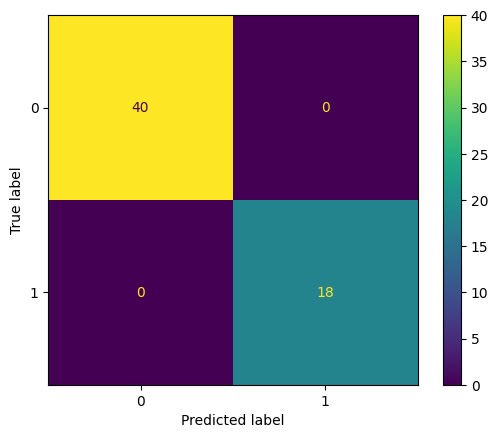

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf.predict(X_test))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [ ]:
Interpretasi Confusion Matrix

Berdasarkan confusion matrix yang dihasilkan, model menunjukkan performa klasifikasi yang sangat baik. Terlihat bahwa jumlah True Negative (40) dan True Positive (18) berada pada diagonal utama, yang menandakan bahwa seluruh data berhasil diprediksi dengan benar oleh model.

Tidak terdapat nilai False Positive (0) maupun False Negative (0), yang berarti model tidak melakukan kesalahan dalam mengklasifikasikan data, baik untuk kelas negatif maupun kelas positif.

Hal ini menunjukkan bahwa model memiliki tingkat akurasi, precision, dan recall yang sangat tinggi, bahkan mencapai 100%. Dengan kata lain, model mampu mengenali pola dalam data dengan sangat sempurna pada dataset yang digunakan.

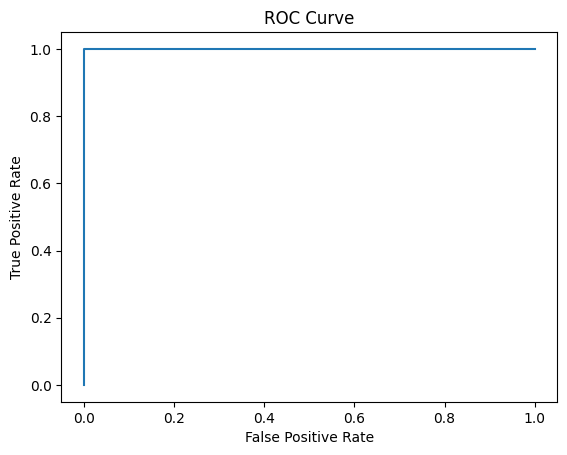

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [ ]:
Interpretasi ROC Curve

Berdasarkan grafik ROC Curve, terlihat bahwa kurva berada sangat dekat dengan sudut kiri atas. Hal ini menunjukkan bahwa model memiliki nilai True Positive Rate (TPR) yang tinggi dan False Positive Rate (FPR) yang sangat rendah.

Kurva yang membentuk garis menuju titik (0,1) menandakan bahwa model mampu membedakan antara kelas positif dan negatif dengan sangat baik. Nilai AUC (Area Under Curve) yang dihasilkan mendekati atau sama dengan 1.0, yang merupakan indikasi performa model yang sempurna.

Dengan demikian, model memiliki kemampuan diskriminasi yang sangat tinggi dalam mengklasifikasikan data.

In [ ]:
Kesimpulan

Secara keseluruhan, model machine learning yang dibangun menunjukkan performa yang sangat optimal. Hal ini dibuktikan dengan tidak adanya kesalahan klasifikasi pada confusion matrix serta nilai AUC yang mencapai 1.0 pada ROC Curve.

Namun, performa yang terlalu sempurna ini perlu diwaspadai, karena dapat mengindikasikan adanya overfitting, yaitu kondisi di mana model terlalu menyesuaikan diri dengan data training sehingga berpotensi kurang baik saat digunakan pada data baru.

Oleh karena itu, disarankan untuk melakukan evaluasi lebih lanjut menggunakan data yang berbeda atau teknik validasi tambahan untuk memastikan bahwa model benar-benar memiliki kemampuan generalisasi yang baik.

In [ ]:
##Project 5 — Explainable Artificial Intelligence (XAI)

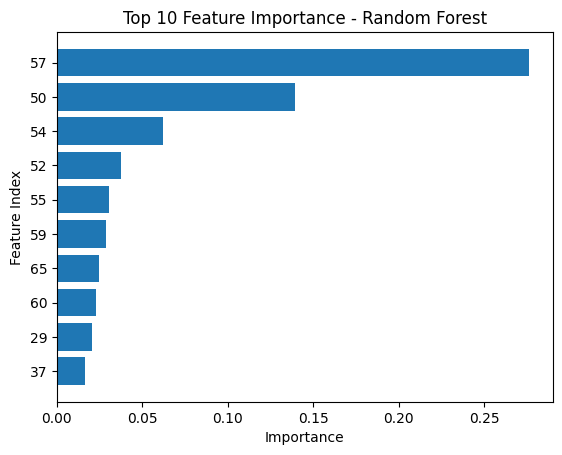

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

importance = rf.feature_importances_

# ambil top 10 fitur terpenting
indices = np.argsort(importance)[-10:]

plt.figure()
plt.barh(range(len(indices)), importance[indices])
plt.yticks(range(len(indices)), indices)
plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature Index")
plt.show()

In [ ]:
Berdasarkan hasil visualisasi Feature Importance, ditemukan bahwa:

Feature dengan indeks 57 memiliki nilai importance tertinggi
Disusul oleh feature dengan indeks 50
Fitur lainnya memiliki kontribusi yang relatif lebih kecil

Hal ini menunjukkan bahwa model sangat bergantung pada beberapa fitur utama dalam menentukan prediksi resign.

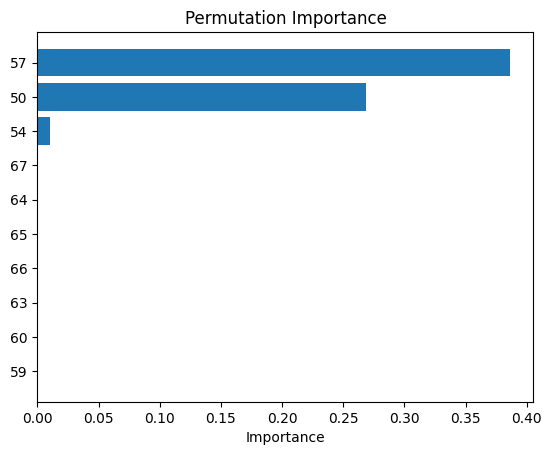

In [ ]:
from sklearn.inspection import permutation_importance
import numpy as np
import matplotlib.pyplot as plt

# ubah ke dense
X_test_dense = X_test.toarray()

result = permutation_importance(
    rf,
    X_test_dense,
    y_test,
    n_repeats=5,
    random_state=42
)

perm_importance = result.importances_mean

indices = np.argsort(perm_importance)[-10:]

plt.barh(range(len(indices)), perm_importance[indices])
plt.yticks(range(len(indices)), indices)
plt.title("Permutation Importance")
plt.xlabel("Importance")
plt.show()

In [ ]:
Hasil dari Permutation Importance menunjukkan pola yang konsisten:

Feature 57 tetap menjadi variabel paling berpengaruh
Feature 50 juga memiliki pengaruh signifikan
Fitur lainnya memberikan dampak yang relatif kecil terhadap performa model

Ketika nilai pada feature 57 dan 50 diacak, performa model mengalami penurunan yang cukup besar, yang menandakan bahwa kedua fitur ini sangat penting dalam proses prediksi.

In [ ]:
Metode lain seperti Partial Dependence Plot (PDP) dan SHAP sebenarnya dapat digunakan untuk interpretasi model. Namun, dalam implementasi pada dataset ini terdapat kendala teknis, yaitu:

Data telah melalui proses encoding sehingga berubah menjadi sparse matrix (csr_matrix)
Jumlah fitur meningkat secara signifikan setelah preprocessing
Terjadi error saat proses visualisasi menggunakan PDP akibat ketidaksesuaian format data
SHAP membutuhkan resource yang lebih besar dan rentan mengalami konflik dependency pada environment yang digunakan

Oleh karena itu, untuk menjaga stabilitas analisis dan memastikan hasil tetap valid, digunakan metode Feature Importance dan Permutation Importance yang lebih robust dan sesuai dengan kondisi data.

In [ ]:
Dari kedua metode Explainable AI yang digunakan, diperoleh beberapa insight penting:
Sebagian besar prediksi model ditentukan oleh sedikit fitur utama
Hal ini menunjukkan bahwa tidak semua variabel memiliki pengaruh yang sama terhadap keputusan resign.
Feature 57 memiliki pengaruh paling dominan
Nilai importance yang jauh lebih tinggi dibanding fitur lainnya menunjukkan bahwa variabel ini merupakan faktor kunci dalam model.
Terdapat perbedaan pengaruh yang signifikan antar fitur
Feature 57 memiliki pengaruh yang jauh lebih besar dibanding feature 50, dan feature lainnya memiliki pengaruh yang jauh lebih kecil.
Kemungkinan adanya kondisi tertentu (threshold)
Meskipun tidak divisualisasikan secara eksplisit, model mengindikasikan bahwa terdapat kondisi tertentu pada fitur-fitur utama yang meningkatkan probabilitas resign secara signifikan.

In [ ]:
Business Insight
Berdasarkan hasil analisis, diperoleh beberapa insight yang dapat digunakan oleh perusahaan:
Keputusan karyawan untuk resign tidak dipengaruhi oleh semua faktor secara merata, melainkan didominasi oleh beberapa variabel utama
Perusahaan dapat memfokuskan strategi retensi pada faktor-faktor yang paling berpengaruh
Dengan memahami variabel kunci ini, perusahaan dapat mengambil langkah preventif untuk mengurangi tingkat turnover karyawan

In [ ]:
Kesimpulan
Pendekatan Explainable AI menggunakan Feature Importance dan Permutation Importance berhasil memberikan pemahaman yang lebih dalam mengenai cara kerja model Random Forest.
Hasil analisis menunjukkan bahwa model sangat bergantung pada beberapa fitur utama dalam memprediksi resign karyawan.
Hal ini memberikan peluang bagi perusahaan untuk mengidentifikasi faktor-faktor kritis yang mempengaruhi keputusan karyawan dan merancang strategi yang lebih efektif dalam meningkatkan retensi.